In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

from sklearn.preprocessing import StandardScaler

import warnings

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(
    "C:/Users/rames/notebook/DS-1/data/processed/final_feature_dataset.csv"
)

In [3]:
print(df.shape)

print(df.isnull().sum().sum())

(114100, 58)
0


In [4]:
popular_products = (

df.groupby(

"product_id"

)

.agg(

{

"order_id":"count",

"total_order_value":"sum"

}

)

.reset_index()

)

In [5]:
popular_products.columns=[

"product_id",

"orders",

"revenue"

]

In [6]:
popular_products["popularity_score"]=(

popular_products["orders"]*0.6+

popular_products["revenue"]*0.4

)

In [7]:
popular_products=popular_products.sort_values(

"popularity_score",

ascending=False

)


In [8]:
popular_products.head(20)

,product_id,orders,revenue,popularity_score
24087,bb50f2e236e5eea0100680137654686c,196,67944.87,27295.548
27040,d1c427060a0f73f6b889a5c7c61f2ac4,343,60976.03,24596.212
14068,6cdd53843498f92890544667809f1595,156,59093.99,23731.196
19742,99a4788cb24856965c36a24e339b6058,491,51391.85,20851.340
27614,d6160fb7873f184099d9bc95e30376af,35,50326.18,20151.472
8051,3dd2a17168ec895c781a9191c1e95ad7,274,48212.22,19449.288
22113,aca2eb7d00ea1a7b8ebd4e68314663af,527,44820.76,18244.504
12351,5f504b3a1c75b73d6151be81eb05bdc9,63,41725.81,16728.124
10867,53b36df67ebb7c41585e8d54d6772e08,323,39957.93,16176.972
4996,25c38557cf793876c5abdd5931f922db,38,40311.95,16147.580


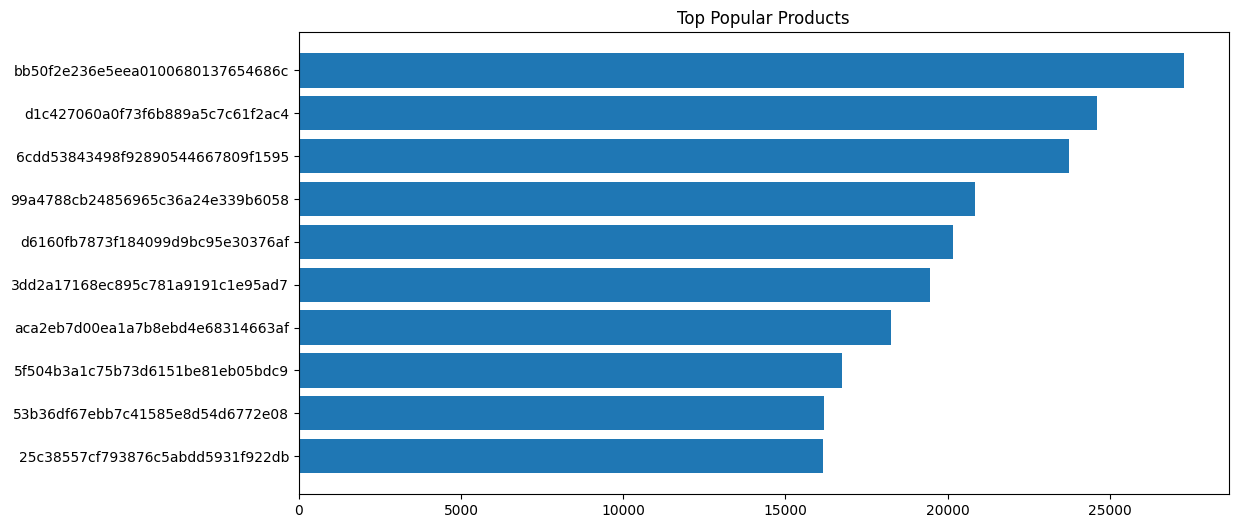

In [9]:
plt.figure(figsize=(12,6))

plt.barh(

popular_products.head(10)["product_id"],

popular_products.head(10)["popularity_score"]

)

plt.gca().invert_yaxis()

plt.title("Top Popular Products")

plt.show()

In [10]:
category_products=(

df.groupby(

["product_category_name_english",

"product_id"]

)

["total_order_value"]

.sum()

.reset_index()

)

In [11]:
category_products=category_products.sort_values(

["product_category_name_english",

"total_order_value"],

ascending=[True,False]

)

In [15]:
category_df = df[
    df["product_category_name_english"] != "Unknown"
].copy()

In [16]:
category_products = (
    category_df
    .groupby(
        ["product_category_name_english", "product_id"]
    )["total_order_value"]
    .sum()
    .reset_index()
)

In [19]:
category_products = category_products.sort_values(
    ["product_category_name_english", "total_order_value"],
    ascending=[True, False]
)

In [20]:
category_recommendation = (
    category_products
    .groupby("product_category_name_english")
    .head(5)
)

In [21]:
category_recommendation.head(20)

,product_category_name_english,product_id,total_order_value
7,agro_industry_and_commerce,11250b0d4b709fee92441c5f34122aed,9710.48
24,agro_industry_and_commerce,423a6644f0aa529e8828ff1f91003690,8609.73
35,agro_industry_and_commerce,672e757f331900b9deea127a2a7b79fd,7355.34
53,agro_industry_and_commerce,c183fd5d2abf05873fa6e1014ed9e06c,6081.54
20,agro_industry_and_commerce,2b69866f22de8dad69c976771daba91c,3184.55
78,air_conditioning,12485f9cdebb6ca179826ede539554ad,3993.09
135,air_conditioning,83ca77d87b187321faaee535adbce26c,2526.58
76,air_conditioning,0e34187d4312b97b5e698836d28ed040,2356.40
174,air_conditioning,ccb162ed569f47d83f62aebd5700d7ad,2154.33
185,air_conditioning,e932008cf0ea7c93a077dd8d7e5f49eb,2089.91


In [22]:
basket=(

df.groupby(

"order_id"

)

["product_id"]

.apply(list)

)

In [23]:
from itertools import combinations

pairs=[]

for products in basket:

    unique_products=list(set(products))

    if len(unique_products)>=2:

        for pair in combinations(

            sorted(unique_products),

            2

        ):

            pairs.append(pair)

In [24]:
pair_df=pd.DataFrame(

pairs,

columns=[

"Product_A",

"Product_B"

]

)

In [25]:
frequently_bought=(

pair_df

.value_counts()

.reset_index(

name="count"

)

.sort_values(

"count",

ascending=False

)

)

In [26]:
frequently_bought.head(20)

,Product_A,Product_B,count
0,36f60d45225e60c7da4558b070ce4b60,e53e557d5a159f5aa2c5e995dfdf244b,34
1,35afc973633aaeb6b877ff57b2793310,99a4788cb24856965c36a24e339b6058,29
2,4fcb3d9a5f4871e8362dfedbdb02b064,f4f67ccaece962d013a4e1d7dc3a61f7,17
3,36f60d45225e60c7da4558b070ce4b60,3f14d740544f37ece8a9e7bc8349797e,12
4,389d119b48cf3043d311335e499d9c6b,422879e10f46682990de24d770e7f83d,11
5,389d119b48cf3043d311335e499d9c6b,53759a2ecddad2bb87a079a1f1519f73,9
6,368c6c730842d78016ad823897a372db,53759a2ecddad2bb87a079a1f1519f73,8
8,18486698933fbb64af6c0a255f7dd64c,dbb67791e405873b259e4656bf971246,7
7,422879e10f46682990de24d770e7f83d,53759a2ecddad2bb87a079a1f1519f73,7
11,060cb19345d90064d1015407193c233d,98d61056e0568ba048e5d78038790e77,6


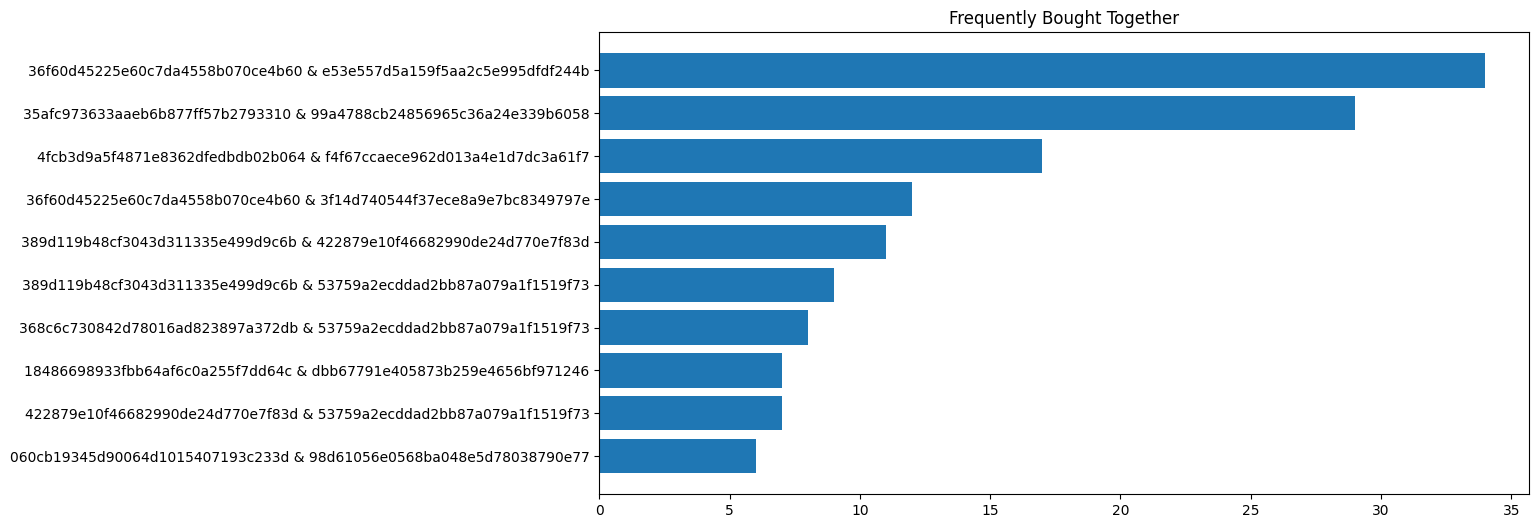

In [27]:
plt.figure(figsize=(12,6))

plt.barh(

range(10),

frequently_bought.head(10)["count"]

)

plt.yticks(

range(10),

frequently_bought.head(10)["Product_A"]

+" & "+

frequently_bought.head(10)["Product_B"]

)

plt.gca().invert_yaxis()

plt.title("Frequently Bought Together")

plt.show()

In [28]:
seller_recommendation=(

df.groupby(

"seller_id"

)

["total_order_value"]

.sum()

.reset_index()

)

In [29]:
seller_recommendation=seller_recommendation.sort_values(

"total_order_value",

ascending=False

)

In [30]:
seller_recommendation.head()

,seller_id,total_order_value
857,4869f7a5dfa277a7dca6462dcf3b52b2,249640.70
1535,7c67e1448b00f6e969d365cea6b010ab,241374.82
881,4a3ca9315b744ce9f8e9374361493884,238440.31
1013,53243585a1d6dc2643021fd1853d8905,235856.68
3025,fa1c13f2614d7b5c4749cbc52fecda94,204084.73


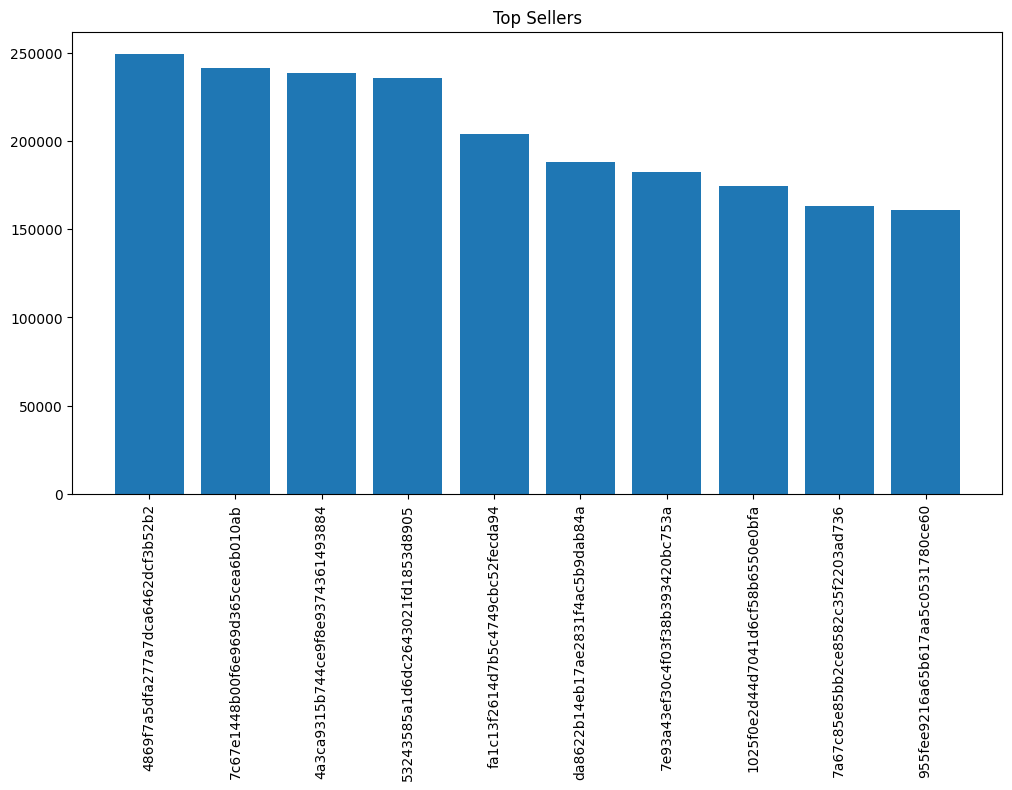

In [31]:
plt.figure(figsize=(12,6))

plt.bar(

seller_recommendation.head(10)["seller_id"],

seller_recommendation.head(10)["total_order_value"]

)

plt.xticks(rotation=90)

plt.title("Top Sellers")

plt.show()

In [32]:
products=df[[

"product_id",

"product_weight_g",

"product_length_cm",

"product_width_cm",

"product_height_cm",

"product_photos_qty",

"product_description_lenght"

]].drop_duplicates()

In [33]:
features=products.drop(

columns=["product_id"]

)

In [34]:
scaler=StandardScaler()

scaled=scaler.fit_transform(

features

)

In [35]:
similarity=cosine_similarity(

scaled

)

In [36]:
similarity_df=pd.DataFrame(

similarity,

index=products["product_id"],

columns=products["product_id"]

)

In [37]:
sample_product=products.iloc[0]["product_id"]

recommendations=(

similarity_df

[sample_product]

.sort_values(

ascending=False

)

.head(6)

)

In [38]:
recommendations

product_id
87285b34884572647811a353c7ac498a    1.000000
aac08ad85d954dfe44e572ad1012d4ed    0.998736
fa7e460c8ef762c029b4042723e481c7    0.996635
6743237ac224ec25a57fcc1b07197f64    0.996215
ab44178963b4bf809adc477810f9175d    0.996134
729e4dedfa3ed50a3fd4898b6f11c715    0.995901
Name: 87285b34884572647811a353c7ac498a, dtype: float64

In [39]:
similar_products=[]

for product in products["product_id"]:

    recs=(

    similarity_df[product]

    .sort_values(

    ascending=False

    )

    .iloc[1:6]

    )

    for rec in recs.index:

        similar_products.append(

        [

        product,

        rec

        ]

        )

In [40]:
similar_products=pd.DataFrame(

similar_products,

columns=[

"Product",

"Recommended_Product"

]

)

In [41]:
popular_products.to_csv(

"C:/Users/rames/notebook/DS-1/reports/recommendation/popular_products.csv",

index=False

)

In [43]:
category_recommendation.to_csv(

"C:/Users/rames/notebook/DS-1/reports/recommendation/category_recommendation.csv",

index=False

)

In [44]:
frequently_bought.to_csv(

"C:/Users/rames/notebook/DS-1/reports/recommendation/frequently_bought.csv",

index=False

)

In [45]:
seller_recommendation.to_csv(

"C:/Users/rames/notebook/DS-1/reports/recommendation/seller_recommendation.csv",

index=False

)

In [46]:
similar_products.to_csv(

"C:/Users/rames/notebook/DS-1/reports/recommendation/similar_products.csv",

index=False

)

# Business Insights

- Popular products account for a significant share of overall sales.
- Frequently bought product pairs can support bundle promotions.
- Category-specific recommendations improve product discovery.
- High-performing sellers contribute a large portion of marketplace revenue.
- Similar product recommendations enable personalized shopping experiences.

# Conclusion

A hybrid recommendation system was developed using multiple recommendation strategies:

- Popularity-based recommendations
- Category-based recommendations
- Frequently bought together analysis
- Seller performance recommendations
- Content-based similarity recommendations

These recommendation datasets can be integrated into the Streamlit dashboard to provide AI-powered product suggestions.